## Решение обратной задачи электростатики

In [62]:
from numpy import linspace, logspace, zeros, exp, linalg, dot, eye
from matplotlib.pyplot import figure, axes, show
import matplotlib.pyplot as plt
import numpy as np

Задаём матрицу системы

<center>$
A = \begin{pmatrix}
\displaystyle\frac{(s_1-x_0)h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_1-x_1)h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_1-x_N)h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\[5 mm]
\displaystyle\frac{(s_2-x_0)h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_2-x_1)h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_2-x_N)h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\[5 mm]
\cdots & \cdots & \cdots & \cdots \\[5 mm]
\displaystyle\frac{(s_{N-1}-x_0)h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_{N-1}-x_1)h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_{N-1}-x_N)h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\end{pmatrix}
$</center>

In [63]:
def system_matrix(N, x, h, N_s, s, l_y, l_z) :
    A = zeros((3*N_s, N+1))

    for j in range(0, 3*N_s, 3):
        A[j,0] = 1/2*(s[int(j/3)] - x[0])*h/((s[int(j/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1, N) :
            A[j,n] = (s[int(j/3)] - x[n])*h/((s[int(j/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*(s[int(j/3)] - x[N])*h/((s[int(j/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    for j in range(1, 3*N_s, 3):
        A[j,0] = 1/2*l_y*h/((s[int((j-1)/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1,N) :
            A[j,n] = l_y*h/((s[int((j-1)/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*l_y*h/((s[int((j-1)/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    for j in range(2, 3*N_s, 3) :
        A[j,0] = 1/2*l_z*h/((s[int((j-2)/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1, N) :
            A[j,n] = l_z*h/((s[int((j-2)/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*l_z*h/((s[int((j-2)/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    return A

Задаём непрерывную (реальную) модель распределения плотности
<center>
$\rho (x) = \displaystyle\frac{2e^{2(x - 0.382)}}{0.009}+\displaystyle\frac{1.2e^{-2(x-0.618)}}{0.018}$
</center>

In [64]:
# Истинное распределение плотности (мы его не знаем)
def rho_model(x) :
    return 2*exp(-(x- 0.382)**2/0.009) + 1.2*exp(-(x- 0.618)**2/0.018)

# Расчитываем значение РЕАЛЬНОГО распределения плотности на заданной сетке
a = 0.; b = 1.

N_model = 100

h_model = (b - a) / N_model
x_model = linspace(a, b, N_model + 1)

X_model= zeros(N_model + 1)
for n in range(N_model + 1) :
    X_model[n] = rho_model(x_model[n])

Подготавливаем правую часть системы $B$, т.е. ту, которую мы измеряем в эксперименте. Моделируем ошибку $\delta$ следующим правилом:
<center>$\Delta = 10^{-8} \\[10pt] $</center>
<center>$b_{\delta} = b_i^{\text{model}}+\delta \cdot \text{rand}[-1, 1] \\[10pt] $</center>
<center>$\delta = \| b^{\text{model}} - b_{\delta} \| \\[10pt] $</center>

In [65]:
# Границы сенсоров (c и d по координате x) и фиксируем координаты y и z (задача одномерная)
c = -1.; d = 2.
l_y= 0.8 ; l_z= 0.2

# Количество сенсоров и разбиваем отрезок на сетку
N_s= 200
x_s = linspace(c, d, N_s)

# Модельное A
A = system_matrix(N_model, x_model, h_model, N_s, x_s, l_y, l_z)

# "Измеренное B"
d = 1e-6
B_model = dot(A,X_model)
B = B_model.copy()
for i in range(len(B)):
    B[i] += d * np.random.uniform(-1, 1)


delta = linalg.norm(B - B_model)
delta

np.float64(1.4334400110136488e-05)

Точное решение системы $A_h X = B_{\delta}$ не существует, т.к. системы задана с ошибками. Поэтому для нахождения наилучшего приближенного решения будем минимизировать функционал Тихонова

<center> $F[X]={\| {AX-B} \|}^2 + \alpha { \| {X} \| }^2 \\[10pt]$ </center>

$\alpha$ - параметр регуляризации. Он помагает справиться с неустойчивостью получаемого решения. Т.к. параметр регуляризации не задан, то для каждого $\alpha_i$ некоторого набора $\alpha$ будем минимизировать функционал методом сопряженных градиентов. $X_{inv}$ - это подходящая нам функция (набор значений функции на сетке), при которой достигается минимум функционала Тихонова. Метод сопряженных градиентов выглядит следующим образом:

#### **Подготовка перед итерационным процессом**

<center> $\forall x^0 \\[5pt] $ </center>
<center> $r^0 = b - Ax^0 \\[5pt] $ </center>
<center> $z = A^T r \\[5pt] $ </center>
<center> $p^0 = z^0$ </center>

#### **$k$-я итерация метода**

<center> $k_1 = \displaystyle\frac{(z, z)}{(Ap, Ap) + (p, p)} \\[15pt] $ </center>
<center> $x = x + k_1p \\[10pt] $ </center>
<center> $r = r - k_1Ap \\[10pt] $ </center>
<center> $k_2 = (z, z) \\[10pt] $ </center>
<center> $z = A^Tr - \alpha x \\[10pt] $ </center>
<center> $p = z + k_2p$ </center>

Метод будет сходиться за $n$ шагов

In [66]:
N = 50
h = (b - a) / N
x = linspace(a, b, N+1)

A = system_matrix(N, x, h, N_s, x_s, l_y, l_z)

Зададим интервал $\alpha = (10^{-15}, 10^{4})$ и посчитаем на $200$ точках значение функционала $\rho(\alpha)= \| {AX-B} \| ^ 2 - \delta^2$

In [67]:
def rho(alpha):
    # Метод сопряженных градиентов (реализация с лекции)

    # Точность
    eps = 1e-12

    # Начальные приближения
    X_inv = np.zeros(N+1)   # x^(0)
    r = B - dot(A, X_inv)   # r^(1)
    z = dot(A.T, r)         # r^(1)
    p = z.copy()            # p^(1)

    # Итерации
    while linalg.norm(z) > eps:
        k1 = dot(z, z) / (dot(dot(A, p), dot(A, p)) + alpha * dot(p, p))    # k1^(n)
        X_inv += k1 * p                                                     # x^(n)
        r -= k1 * dot(A, p)                                                 # r^(n)
        k2 = dot(z, z)                                                      # k2^(n)
        z = dot(A.T, r) - alpha * X_inv                                     # z^(n)
        k2 = dot(z, z) / k2                                                 # k2^(n)
        p = z + k2 * p                                                      # p^(n)

    return linalg.norm(dot(A, X_inv) - B)**2  - delta**2

In [68]:
r = list()
alphas = logspace(-15, 4, 200)

for a in alphas:
    r.append(rho(a))

r = np.array(r)

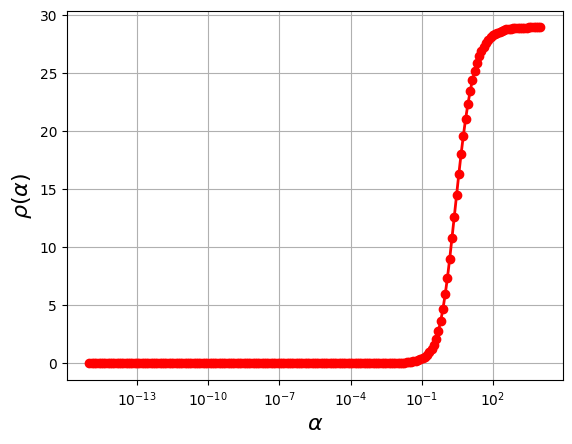

In [69]:
plt.figure()

plt.plot(alphas, r, '-or', lw=2)

plt.xscale('log')   # логарифмическая ось alpha
plt.xlabel(r'$\alpha$', fontsize=16)          # alpha как LaTeX
plt.ylabel(r'$\rho(\alpha)$', fontsize=16)    # rho(alpha) как LaTeX

plt.grid(True)

plt.show()

 Чтобы найти оптимальное значение параметра регуляризации $\alpha$, необходимо найти пересечение графика $\rho(\alpha)$ с осью $\alpha$. Будем искать решение уравнения $\rho(\alpha)=0$ численно - методом Дихотомии. Выберем в качестве начальных границ интервала значения $10^{-15}$ и $10^{-8}$

In [70]:
a1 = 1e-30      # левая граница
a2 = 1e2       # правая граница
eps = 1e-15     # точность решения

# Начальное приближения
alpha = (a1 + a2) / 2
f1 = rho(a1)
f2 = rho(a2)

# Проверка знаков функции на границах
if f1 * f2 > 0:
    raise ValueError("На интервале нет смены знака")

# Итерация
while abs(rho(alpha)) > eps:
    f = rho(alpha)
    if f1 * f < 0:
        a2 = alpha
        f2 = f
    else:
        a1 = alpha
        f1 = f

    alpha = (a1 + a2) / 2

alpha

2.9870550477539837e-11

Итак, находим оптимальное $\alpha$. Найдем решение (методом сопряженных градиентов) с оптимальным параметром регуляризации

In [71]:
# Метод сопряженных градиентов (реализация с лекции)

# Точность
eps = 1e-12

# Начальные приближения
X_inv = np.zeros(N+1)   # x^(0)
r = B - dot(A, X_inv)   # r^(1)
z = dot(A.T, r)         # r^(1)
p = z.copy()            # p^(1)

# Итерации
while linalg.norm(z) > eps:
    k1 = dot(z, z) / (dot(dot(A, p), dot(A, p)) + alpha * dot(p, p))    # k1^(n)
    X_inv += k1 * p                                                     # x^(n)
    r -= k1 * dot(A, p)                                                 # r^(n)
    k2 = dot(z, z)                                                      # k2^(n)
    z = dot(A.T, r) - alpha * X_inv                                     # z^(n)
    k2 = dot(z, z) / k2                                                 # k2^(n)
    p = z + k2 * p                                                      # p^(n)


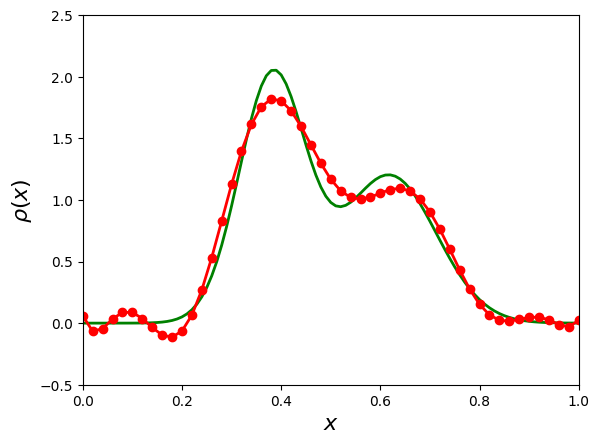

In [72]:
# Отрисовка решения
plt.style.use('default')

fig = figure()
ax = axes(xlim=(0,1), ylim=(-0.5,2.5))
ax.set_xlabel(r'$x$', fontsize=16); ax.set_ylabel(r'$\rho (x)$', fontsize=16)
ax.plot(x_model,X_model,'-g',lw=2)
ax.plot(x,X_inv,'-or',lw=2)
show()